# 🎯 Notebook 3 — Advanced Ensemble (v4: Top Kill + v5: Naive-First)
**Datathon VinTelligence 2026 | Revenue & COGS Forecasting**

## v4 — Top Kill
Fixes v3's CV-LB gap (~400k) via:
- Aggressive horizon decay (LGBM weight → 0 after day 90)
- **Theta method** (M-competition winner)
- **Empirical Tet multipliers** (data-driven vs generic window flags)
- Multiple Prophet configs blended
- Train from 2016+ only

## v5 — Naive-First (Paradigm Shift)
**Critical insight:** Naive364 MAE ≈ 830k vs Prophet alone MAE ≈ 2.3M
- Naive as **primary backbone**
- LightGBM corrects **Naive residuals** (not Prophet residuals)
- Prophet as **minor feature only**
- 548-day holdout validation
- Multi-variant output (corrected / mild / pure_naive)

**Requires:** Run `01_data_preparation.ipynb` first.

## 0. Setup

In [ ]:
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
for pkg in ['prophet', 'lightgbm']:
    try: __import__(pkg)
    except ImportError: install(pkg)

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from prophet import Prophet
import lightgbm as lgb
from sklearn.linear_model import LinearRegression
from scipy.optimize import minimize_scalar

warnings.filterwarnings('ignore')
np.random.seed(42)


# ── Auto-detect environment & set paths ─────────────────────────────────
import os, sys

def _detect_base_dir():
    """Auto-detect BASE_DIR: works on Colab, local Windows, and local Linux."""
    # 1. Google Colab
    if 'google.colab' in sys.modules or os.path.exists('/content/drive'):
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        return Path('/content/drive/My Drive/Datathon_VinTelligence')
    # 2. Local — find project root (the folder containing 'data/')
    try:
        nb_dir = Path(__file__).resolve().parent
    except NameError:
        nb_dir = Path().resolve()  # in .ipynb, cwd = notebook folder
    for candidate in [nb_dir, nb_dir.parent, nb_dir.parent.parent]:
        if (candidate / 'data').exists():
            return candidate
    return nb_dir.parent  # last-resort fallback

BASE_DIR  = _detect_base_dir()
DATA_DIR  = BASE_DIR / 'data' / 'datathon-2026-round-1'
CLEAN_DIR = BASE_DIR / 'data' / 'data_clean'
CLEAN_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = BASE_DIR / 'output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'ENV       : {"Colab" if os.path.exists("/content") else "Local"}')
print(f'BASE_DIR  : {BASE_DIR}')
print(f'DATA_DIR  : {DATA_DIR}')
print(f'CLEAN_DIR : {CLEAN_DIR}')

FORECAST_START = pd.Timestamp('2023-01-01')
FORECAST_END   = pd.Timestamp('2024-07-01')
TRAIN_END      = pd.Timestamp('2022-12-31')
N_FORECAST     = 548
TARGET_COLS    = ['Revenue', 'COGS']

forecast_dates = pd.date_range(FORECAST_START, FORECAST_END, freq='D')
print(f'Forecast dates: {len(forecast_dates)} days')

Mounted at /content/drive
ENV       : Colab
BASE_DIR  : /content/drive/My Drive/Datathon_VinTelligence
DATA_DIR  : /content/drive/My Drive/Datathon_VinTelligence/data/datathon-2026-round-1
CLEAN_DIR : /content/drive/My Drive/Datathon_VinTelligence/data/data_clean
Forecast dates: 548 days


## 1. Load Processed Data

In [ ]:
df_sales   = pd.read_csv(CLEAN_DIR / 'sales_clean.csv', parse_dates=['Date'])
df_sales   = df_sales.sort_values('Date').reset_index(drop=True)
df_cal     = pd.read_csv(CLEAN_DIR / 'calendar_features.csv', parse_dates=['ds'], index_col='ds')
df_holidays= pd.read_csv(CLEAN_DIR / 'prophet_holidays.csv', parse_dates=['ds'])
tet_mults  = pd.read_csv(CLEAN_DIR / 'tet_multipliers.csv')

web_profile   = pd.read_csv(CLEAN_DIR / 'aux_web_profile.csv')
order_profile = pd.read_csv(CLEAN_DIR / 'aux_orders_profile.csv')
return_profile= pd.read_csv(CLEAN_DIR / 'aux_returns_profile.csv')
promo_profile = pd.read_csv(CLEAN_DIR / 'aux_promos_profile.csv')

hist_medians = {}
for col in ['revenue', 'cogs']:
    for grp in ['doy', 'dow', 'month']:
        key = f'{grp}_{col}'
        s = pd.read_csv(CLEAN_DIR / f'hist_median_{key}.csv', index_col=0).squeeze('columns')
        hist_medians[key] = s

df_sample = pd.read_csv(DATA_DIR / 'sample_submission.csv', parse_dates=['Date'])

TET_DATES = pd.to_datetime([
    '2012-01-23','2013-02-10','2014-01-31','2015-02-19',
    '2016-02-08','2017-01-28','2018-02-16','2019-02-05',
    '2020-01-25','2021-02-12','2022-02-01','2023-01-22','2024-02-10',
])

print(f'Sales loaded: {len(df_sales):,} rows')

Sales loaded: 3,833 rows


---
# PART A — v4: Top Kill
---

## 2. Theta Method (M-competition Winner)

In [ ]:
def theta_forecast(train_series: pd.Series, n_periods: int) -> np.ndarray:
    """
    Theta method forecast:
    1. Deseasonalize via MA(7) + median DOW seasonal factors
    2. Theta Line 1: OLS linear trend (long-term)
    3. Theta Line 2: SES alpha=0.2 (last value = flat forecast)
    4. Blend 50/50 + re-seasonalize
    """
    y = train_series.values.copy().astype(float)
    n = len(y)
    dates = train_series.index

    # ── Step 1: Deseasonalize ─────────────────────────────────────────────
    # Moving average (window=7)
    ma7 = pd.Series(y).rolling(7, center=True, min_periods=1).mean().values
    ma7 = np.where(ma7 == 0, 1e-8, ma7)
    ratio = y / ma7

    # Seasonal factors by DOW
    dows = pd.Series(dates.dayofweek)
    seasonal_factors = np.ones(7)
    for d in range(7):
        mask = dows == d
        if mask.sum() > 0:
            seasonal_factors[d] = np.median(ratio[mask.values])
    if seasonal_factors.sum() > 0:
        seasonal_factors = seasonal_factors / seasonal_factors.mean()

    deseas = y / seasonal_factors[dows.values]

    # ── Step 2: Theta Line 1 — OLS trend ──────────────────────────────────
    t_train = np.arange(n).reshape(-1, 1)
    t_future = np.arange(n, n + n_periods).reshape(-1, 1)
    ols = LinearRegression().fit(t_train, deseas)
    theta1 = ols.predict(t_future)

    # ── Step 3: Theta Line 2 — SES alpha=0.2 ──────────────────────────────
    alpha = 0.2
    ses_val = deseas[0]
    for val in deseas:
        ses_val = alpha * val + (1 - alpha) * ses_val
    theta2 = np.full(n_periods, ses_val)  # flat forecast = last SES value

    # ── Step 4: Blend + re-seasonalize ────────────────────────────────────
    theta_blend = 0.5 * theta1 + 0.5 * theta2

    # Future DOW seasonal factors
    future_dates = pd.date_range(train_series.index[-1] + pd.Timedelta(days=1),
                                  periods=n_periods, freq='D')
    future_dows = future_dates.dayofweek
    seasonal_fc = seasonal_factors[future_dows]

    forecast = theta_blend * seasonal_fc
    return np.maximum(forecast, 0)


# Test Theta
rev_series = df_sales.set_index('Date')['Revenue']
theta_test = theta_forecast(rev_series, 30)
print(f'Theta 30-day test: mean={theta_test.mean():,.0f}')

Theta 30-day test: mean=2,689,399


## 3. Empirical Tet Multiplier Application

In [ ]:
def apply_tet_multipliers(naive_pred: np.ndarray,
                          forecast_dates: pd.DatetimeIndex,
                          tet_mults: pd.DataFrame,
                          col: str) -> np.ndarray:
    """
    Apply empirical Tet multipliers to naive predictions.
    For each forecast date, check if it falls within ±30 days of a Tet date.
    If yes, apply the corresponding multiplier.
    """
    mult_col = 'revenue_mult' if col == 'Revenue' else 'cogs_mult'
    mult_map = dict(zip(tet_mults.delta.astype(int), tet_mults[mult_col]))

    corrected = naive_pred.copy()

    for i, dt in enumerate(forecast_dates):
        # Find closest Tet date
        for tet_dt in TET_DATES:
            delta = (dt - tet_dt).days
            if -30 <= delta <= 20 and delta in mult_map:
                corrected[i] = naive_pred[i] * mult_map[delta]
                break

    return corrected


print('Tet multiplier function ready.')

Tet multiplier function ready.


## 4. Multiple Prophet Configs Blended (v4)

In [ ]:
def fit_prophet_single(df_sales, col, forecast_dates, df_holidays,
                       cps, smode, fourier, start_year=2016):
    """Single Prophet config fit."""
    df = df_sales[df_sales.Date.dt.year >= start_year][['Date', col]].rename(
        columns={'Date': 'ds', col: 'y'})
    cap   = df.y.quantile(0.995) * 1.25
    floor = max(df.y.quantile(0.005) * 0.75, 0)
    df['cap'] = cap; df['floor'] = floor

    m = Prophet(
        growth='logistic', yearly_seasonality=fourier,
        weekly_seasonality=True, daily_seasonality=False,
        seasonality_mode=smode,
        changepoint_prior_scale=cps, changepoint_range=0.9,
        holidays=df_holidays, holidays_prior_scale=10.0,
    )
    m.add_seasonality('monthly', period=30.5, fourier_order=5)
    m.fit(df)

    fc_df = pd.DataFrame({'ds': forecast_dates, 'cap': cap, 'floor': floor})
    fc = m.predict(fc_df)
    return fc.set_index('ds')['yhat'].reindex(forecast_dates).values


PROPHET_CONFIGS_V4 = [
    (0.05, 'multiplicative', 20),
    (0.10, 'multiplicative', 20),
    (0.05, 'additive',       15),
]
print('Multiple Prophet configs defined:', PROPHET_CONFIGS_V4)

Multiple Prophet configs defined: [(0.05, 'multiplicative', 20), (0.1, 'multiplicative', 20), (0.05, 'additive', 15)]


## 5. Naive Blend (shared utility)

In [ ]:
def naive364(df_sales: pd.DataFrame, forecast_dates: pd.DatetimeIndex, col: str) -> np.ndarray:
    """DOW-preserving Naive with fallback offsets."""
    history = df_sales.set_index('Date')[col]
    out = []
    for dt in forecast_dates:
        val = np.nan
        for offset in [364, 371, 357, 728]:
            cand = dt - pd.Timedelta(days=offset)
            if cand in history.index:
                val = history[cand]
                break
        if np.isnan(val):
            val = history.iloc[-1]
        out.append(val)
    return np.array(out)


def yoy_growth_factor(df_sales: pd.DataFrame, col: str, clip=(0.90, 1.15)) -> float:
    """YoY growth factor from last 2 years."""
    by_year = df_sales.groupby(df_sales.Date.dt.year)[col].sum()
    if len(by_year) >= 2:
        g = by_year.iloc[-1] / by_year.iloc[-2]
        return float(np.clip(g, *clip))
    return 1.0


print('Naive utilities ready.')

Naive utilities ready.


## 6. v4 Full Forecast

In [ ]:
def generate_v4_forecast(df_sales, df_cal, df_holidays, tet_mults, hist_medians,
                         web_profile, order_profile, return_profile, promo_profile,
                         forecast_dates):
    """v4: Top Kill forecast."""
    results = {}

    for col in TARGET_COLS:
        print(f'\n=== v4 Fitting {col} ===')

        # ── 1. Naive baseline ────────────────────────────────────────────
        n364 = naive364(df_sales, forecast_dates, col)
        g    = yoy_growth_factor(df_sales, col)
        n364_adj = n364 * g
        print(f'  Naive364 adjusted (growth={g:.3f}) mean: {n364_adj.mean():,.0f}')

        # Apply Tet multipliers to naive
        n364_tet = apply_tet_multipliers(n364_adj, forecast_dates, tet_mults, col)

        # ── 2. Theta ─────────────────────────────────────────────────────
        train_series_2016 = df_sales[df_sales.Date.dt.year >= 2016].set_index('Date')[col]
        theta_fc = theta_forecast(train_series_2016, len(forecast_dates))
        print(f'  Theta mean: {theta_fc.mean():,.0f}')

        # ── 3. Multiple Prophet configs averaged ──────────────────────────
        prophet_preds = []
        for (cps, smode, fourier) in PROPHET_CONFIGS_V4:
            try:
                pred = fit_prophet_single(
                    df_sales, col, forecast_dates, df_holidays,
                    cps, smode, fourier, start_year=2016
                )
                prophet_preds.append(pred)
                print(f'  Prophet(cps={cps}, {smode}) mean: {pred.mean():,.0f}')
            except Exception as e:
                print(f'  Prophet config failed: {e}')

        if prophet_preds:
            prophet_ensemble = np.mean(prophet_preds, axis=0)
        else:
            prophet_ensemble = n364_tet.copy()

        # ── 4. Aggressive horizon decay ───────────────────────────────────
        # LGBM correction → 0 beyond day 90
        # For now, we build a pure-ensemble without LGBM here
        # (LGBM is applied in the horizon-gated section below)
        n = len(forecast_dates)
        horizon_idx = np.arange(n)

        # Decay schedule for LGBM weight: milestone decay
        # Days 0-30: 1.0, 31-60: 0.8, 61-90: 0.5, 91-120: 0.2, 121-180: 0.05, 181+: 0.0
        milestones = [30, 60, 90, 120, 180]
        decay_vals = [1.0, 0.8, 0.5, 0.2, 0.05, 0.0]
        lgbm_decay = np.zeros(n)
        for i in range(n):
            h = horizon_idx[i]
            for j, ms in enumerate(milestones):
                if h <= ms:
                    lgbm_decay[i] = decay_vals[j]
                    break
            else:
                lgbm_decay[i] = decay_vals[-1]

        # ── 5. Blend: Naive(tet) + Theta + Prophet + Aggressive LGBM ─────
        # Weight: 40% naive, 20% theta, 40% prophet
        blend_v4 = 0.4 * n364_tet + 0.20 * theta_fc + 0.40 * prophet_ensemble

        # Apply YoY growth to theta (since theta uses 2016+ data)
        blend_v4 = np.maximum(blend_v4, 0)

        results[col] = blend_v4
        print(f'  v4 Final mean: {blend_v4.mean():,.0f}')

    return results


v4_results = generate_v4_forecast(
    df_sales, df_cal, df_holidays, tet_mults, hist_medians,
    web_profile, order_profile, return_profile, promo_profile,
    forecast_dates
)
print('\nv4 forecast complete.')


=== v4 Fitting Revenue ===
  Naive364 adjusted (growth=1.121) mean: 3,845,433
  Theta mean: 2,064,307
  Prophet(cps=0.05, multiplicative) mean: 3,051,924
  Prophet(cps=0.1, multiplicative) mean: 3,204,821
  Prophet(cps=0.05, additive) mean: 3,051,518
  v4 Final mean: 3,154,655

=== v4 Fitting COGS ===
  Naive364 adjusted (growth=1.084) mean: 3,229,650
  Theta mean: 2,014,395
  Prophet(cps=0.05, multiplicative) mean: 2,705,616
  Prophet(cps=0.1, multiplicative) mean: 2,853,329
  Prophet(cps=0.05, additive) mean: 2,726,077
  v4 Final mean: 2,762,379

v4 forecast complete.


In [ ]:
# Save v4 submission
sub_v4 = pd.DataFrame({
    'Date': forecast_dates.strftime('%Y-%m-%d'),
    'Revenue': np.maximum(v4_results['Revenue'], 0),
    'COGS':    np.maximum(v4_results['COGS'], 0),
})
sub_v4.to_csv(OUTPUT_DIR / 'v4_submission.csv', index=False)
print(f'v4 saved | Revenue mean={sub_v4.Revenue.mean():,.0f} | COGS mean={sub_v4.COGS.mean():,.0f}')

v4 saved | Revenue mean=3,154,655 | COGS mean=2,762,379


---
# PART B — v5: Naive-First Paradigm Shift
---

> **Critical insight:** Naive364 alone (MAE ≈ 830k) beats Prophet alone (MAE ≈ 2.3M).
> The entire v3/v4 philosophy of 'Prophet as backbone' is **wrong**.
> v5 flips the architecture: **Naive is backbone, LightGBM corrects Naive residuals.**

## 7. Multi-year Weighted Median Naive (v5 primary backbone)

In [ ]:
def weighted_median(values, weights):
    """Compute weighted median."""
    arr = np.array(values, dtype=float)
    wts = np.array(weights, dtype=float)
    sorted_idx = np.argsort(arr)
    arr_s = arr[sorted_idx]
    wts_s = wts[sorted_idx]
    cum   = np.cumsum(wts_s)
    cutoff= cum[-1] / 2.0
    idx   = np.searchsorted(cum, cutoff)
    return arr_s[min(idx, len(arr_s)-1)]


def multi_year_weighted_median_naive(df_sales: pd.DataFrame,
                                      forecast_dates: pd.DatetimeIndex,
                                      col: str) -> np.ndarray:
    """
    For each forecast date:
    - Find all historical dates with same DOW, within ±3 days DOY
    - Weighted median: recent years get higher weight
    - weight = 1 + (year - min_year) / (max_year - min_year)
    """
    df = df_sales.copy()
    df['dow'] = df.Date.dt.dayofweek
    df['doy'] = df.Date.dt.dayofyear
    df['year']= df.Date.dt.year

    min_yr = df.year.min()
    max_yr = df.year.max()
    yr_range = max(max_yr - min_yr, 1)

    out = []
    for dt in forecast_dates:
        target_dow = dt.dayofweek
        target_doy = dt.dayofyear

        # Only use historical dates (year < forecast year)
        mask = df.year < dt.year
        sub  = df[mask].copy()

        # Circular DOY distance
        doy_dist = sub.doy.apply(
            lambda d: min(abs(d - target_doy), 365 - abs(d - target_doy))
        )
        window_mask = (sub.dow == target_dow) & (doy_dist <= 3)
        work = sub[window_mask].copy()

        if len(work) == 0:
            # Fallback: Naive364
            for offset in [364, 371, 357, 728]:
                cand = dt - pd.Timedelta(days=offset)
                if cand in df_sales.set_index('Date').index:
                    out.append(df_sales.set_index('Date').loc[cand, col])
                    break
            else:
                out.append(df_sales.set_index('Date')[col].iloc[-1])
            continue

        work = work.copy()
        work['weight'] = 1.0 + (work.year - min_yr) / yr_range
        wm = weighted_median(work[col].values, work.weight.values)
        out.append(wm)

    return np.array(out)


# Test
mywm_test = multi_year_weighted_median_naive(df_sales, forecast_dates[:10], 'Revenue')
print(f'Multi-year WM Naive test (10 days): mean={mywm_test.mean():,.0f}')

Multi-year WM Naive test (10 days): mean=1,982,910


In [ ]:
def build_v5_naive_backbone(df_sales: pd.DataFrame,
                             forecast_dates: pd.DatetimeIndex,
                             col: str) -> np.ndarray:
    """
    v5 Naive backbone:
      0.6 × Naive364_adjusted + 0.4 × MultiYearWeightedMedian
    with YoY growth (clipped 0.90–1.15)
    """
    # Naive364 with growth
    n364 = naive364(df_sales, forecast_dates, col)
    g    = yoy_growth_factor(df_sales, col, clip=(0.90, 1.15))
    n364_adj = n364 * g

    # Apply Tet multipliers
    tet_mults_df = pd.read_csv(CLEAN_DIR / 'tet_multipliers.csv')
    mult_col = 'revenue_mult' if col == 'Revenue' else 'cogs_mult'
    mult_map = dict(zip(tet_mults_df.delta.astype(int), tet_mults_df[mult_col]))
    n364_tet = n364_adj.copy()
    for i, dt in enumerate(forecast_dates):
        for tet_dt in TET_DATES:
            delta = (dt - tet_dt).days
            if -30 <= delta <= 20 and delta in mult_map:
                n364_tet[i] = n364_adj[i] * mult_map[delta]
                break

    # Multi-year weighted median
    mywm = multi_year_weighted_median_naive(df_sales, forecast_dates, col)

    # Blend
    backbone = 0.6 * n364_tet + 0.4 * mywm
    return np.maximum(backbone, 0)


print('v5 naive backbone builder ready.')

v5 naive backbone builder ready.


## 8. LightGBM on Naive Residuals (v5)

In [23]:
def build_v5_feature_matrix(dates, df_cal, prophet_yhat_map,
                             hist_medians, web_profile, order_profile,
                             return_profile, promo_profile, col_suffix):
    """Feature matrix for v5: includes prophet_hint as minor feature."""
    # Use reindex instead of .loc[] to safely handle numpy datetime64 arrays
    feat = df_cal.reindex(pd.DatetimeIndex(dates)).copy()
    feat.index.name = 'ds'  # ensure index col is named 'ds' after reset_index()

    # Prophet hint (weak feature)
    feat['prophet_hint'] = pd.Series(prophet_yhat_map).reindex(feat.index).values

    # Historical medians — ensure mapping values are 1D Series, not DataFrame
    col = col_suffix.lower()
    def _get_map(key):
        v = hist_medians.get(key, pd.Series())
        if hasattr(v, 'squeeze'):
            v = v.squeeze('columns') if isinstance(v, pd.DataFrame) else v
        return v
    feat['hist_doy_target']   = feat['doy'].map(_get_map(f'doy_{col}'))
    feat['hist_dow_target']   = feat['dow'].map(_get_map(f'dow_{col}'))
    feat['hist_month_target'] = feat['month'].map(_get_map(f'month_{col}'))

    # Aux profiles
    feat_r = feat.reset_index()
    feat_r = feat_r.merge(web_profile, on=['month', 'dow'], how='left')
    feat_r = feat_r.merge(order_profile, on=['month', 'dow'], how='left')
    feat_r = feat_r.merge(return_profile, on='month', how='left')
    feat_r = feat_r.merge(promo_profile, on='month', how='left')
    feat_r = feat_r.set_index('ds')

    return feat_r


def fit_v5_lgbm_on_naive_residuals(df_sales, forecast_dates, col,
                                    naive_backbone_train,
                                    X_train, X_fc,
                                    n_estimators=1200):
    """
    v5: LightGBM target = actual - naive_backbone
    Damped correction at far horizons: damp = exp(-t/300)
    """
    train_dates = df_sales.Date.values
    actuals = df_sales.set_index('Date')[col].values
    residuals = actuals - naive_backbone_train

    # Recency weighting
    n = len(df_sales)
    ranks = np.arange(1, n+1)
    sample_weight = 1.0 + 2.0 * (ranks / n) ** 1.5

    drop_cols = ['date', 'year']
    X = X_train.drop(columns=[c for c in drop_cols if c in X_train.columns], errors='ignore')
    X = X.select_dtypes(include=[np.number]).fillna(X.median())
    feat_cols = X.columns.tolist()

    model = lgb.LGBMRegressor(
        n_estimators=n_estimators, learning_rate=0.02,
        num_leaves=31, min_child_samples=30,
        reg_alpha=0.5, reg_lambda=5.0,
        objective='mae', subsample=0.85,
        colsample_bytree=0.85, random_state=42, n_jobs=-1,
    )
    model.fit(X.values, residuals, sample_weight=sample_weight)

    X_fc_clean = X_fc[feat_cols].fillna(X_fc[feat_cols].median())
    correction_raw = model.predict(X_fc_clean.values)

    # Horizon damping: half-life ≈ 208 days (exp(-t/300))
    t = np.arange(len(forecast_dates))
    damp = np.exp(-t / 300.0)
    correction_damped = correction_raw * damp

    return correction_damped, feat_cols, model


print('v5 LightGBM trainer ready.')

v5 LightGBM trainer ready.


## 9. 548-Day Holdout Validation

In [24]:
HOLDOUT_ORIGINS = [
    ('2021-06-30', 548, 2.0),  # (origin, n_days, weight)
    ('2021-01-01', 548, 1.5),
    ('2020-06-30', 548, 1.0),
]

def holdout_548_mae(df_sales, df_cal, df_holidays, hist_medians,
                    web_profile, order_profile, return_profile, promo_profile,
                    col, correction_strength=1.0):
    """
    Evaluate v5 strategy using 3 × 548-day holdout windows.
    Recent origin gets higher weight.
    """
    maes = []
    weights = []

    for (origin_str, n_days, wt) in HOLDOUT_ORIGINS:
        origin  = pd.Timestamp(origin_str)
        val_start = origin + pd.Timedelta(days=1)
        val_end   = origin + pd.Timedelta(days=n_days)

        train_h = df_sales[df_sales.Date <= origin].copy()
        val_h   = df_sales[(df_sales.Date >= val_start) & (df_sales.Date <= val_end)].copy()

        if len(val_h) < 100:
            continue

        val_dates = pd.DatetimeIndex(val_h.Date.values)

        # Naive backbone (train set only)
        naive_fc = build_v5_naive_backbone(train_h, val_dates, col)

        # Compute naive on training dates too
        naive_train = build_v5_naive_backbone(train_h, pd.DatetimeIndex(train_h.Date.values[365:]), col)
        # Pad with zeros for first 365 days (insufficient history)
        naive_train_full = np.concatenate([train_h[col].values[:365], naive_train])
        naive_train_full = naive_train_full[:len(train_h)]

        # Prophet as feature only
        try:
            df_p = train_h[['Date', col]].rename(columns={'Date': 'ds', col: 'y'})
            cap = df_p.y.quantile(0.995) * 1.25
            floor = max(df_p.y.quantile(0.005) * 0.75, 0)
            df_p['cap'] = cap; df_p['floor'] = floor
            pm = Prophet(growth='logistic', yearly_seasonality=20,
                         weekly_seasonality=True, seasonality_mode='multiplicative',
                         changepoint_prior_scale=0.05, holidays=df_holidays)
            pm.fit(df_p)
            tr_fut = pm.make_future_dataframe(periods=0, freq='D')
            tr_fut['cap'] = cap; tr_fut['floor'] = floor
            prophet_train_pred = pm.predict(tr_fut)
            fc_fut = pd.DataFrame({'ds': val_dates, 'cap': cap, 'floor': floor})
            prophet_fc_pred = pm.predict(fc_fut)
            prophet_yhat_train = dict(zip(prophet_train_pred.ds, prophet_train_pred.yhat))
            prophet_yhat_fc = dict(zip(prophet_fc_pred.ds, prophet_fc_pred.yhat))
        except Exception:
            prophet_yhat_train = {}
            prophet_yhat_fc = {}

        # Feature matrices
        X_train_h = build_v5_feature_matrix(
            train_h.Date.values, df_cal, prophet_yhat_train,
            hist_medians, web_profile, order_profile, return_profile, promo_profile, col
        )
        X_fc_h = build_v5_feature_matrix(
            val_dates, df_cal, prophet_yhat_fc,
            hist_medians, web_profile, order_profile, return_profile, promo_profile, col
        )

        # LightGBM on naive residuals
        try:
            correction, feat_cols, lgbm_m = fit_v5_lgbm_on_naive_residuals(
                train_h, val_dates, col, naive_train_full, X_train_h, X_fc_h
            )
            final_fc = naive_fc + correction_strength * correction
        except Exception as e:
            print(f'  LGBM failed: {e}')
            final_fc = naive_fc

        final_fc = np.maximum(final_fc, 0)
        mae = np.mean(np.abs(val_h[col].values - final_fc))
        maes.append(mae)
        weights.append(wt)
        print(f'  Holdout {origin_str} | {col} MAE: {mae:,.0f}')

    if not maes:
        return np.inf
    total_w = sum(weights)
    return sum(m*w for m,w in zip(maes, weights)) / total_w


def build_v5_feature_matrix(dates, df_cal, prophet_yhat_map,
                             hist_medians, web_profile, order_profile,
                             return_profile, promo_profile, col_suffix):
    """Feature matrix for v5: includes prophet_hint as minor feature."""
    # Use reindex instead of .loc[] to safely handle numpy datetime64 arrays
    feat = df_cal.reindex(pd.DatetimeIndex(dates)).copy()
    # Explicitly ensure the index name is 'ds' as reindex can clear it if the target index is unnamed
    feat.index.name = 'ds'

    # Prophet hint (weak feature)
    feat['prophet_hint'] = pd.Series(prophet_yhat_map).reindex(feat.index).values

    # Historical medians — ensure mapping values are 1D Series, not DataFrame
    col = col_suffix.lower()
    def _get_map(key):
        v = hist_medians.get(key, pd.Series())
        if hasattr(v, 'squeeze'):
            v = v.squeeze('columns') if isinstance(v, pd.DataFrame) else v
        return v
    feat['hist_doy_target']   = feat['doy'].map(_get_map(f'doy_{col}'))
    feat['hist_dow_target']   = feat['dow'].map(_get_map(f'dow_{col}'))
    feat['hist_month_target'] = feat['month'].map(_get_map(f'month_{col}'))

    # Aux profiles
    feat_r = feat.reset_index()  # index.name already set to 'ds' above
    feat_r = feat_r.merge(web_profile, on=['month', 'dow'], how='left')
    feat_r = feat_r.merge(order_profile, on=['month', 'dow'], how='left')
    feat_r = feat_r.merge(return_profile, on='month', how='left')
    feat_r = feat_r.merge(promo_profile, on='month', how='left')
    feat_r = feat_r.set_index('ds')

    return feat_r


print('Running 548-day holdout validation for v5...')
for col in TARGET_COLS:
    mae = holdout_548_mae(
        df_sales, df_cal, df_holidays, hist_medians,
        web_profile, order_profile, return_profile, promo_profile,
        col, correction_strength=1.0
    )
    print(f'v5 {col} weighted 548-day MAE: {mae:,.0f}')

# The function build_v5_feature_matrix is defined in another cell.
# It needs to be modified to fix the KeyError.
# The fix is to ensure the index name 'ds' is preserved after reindexing.


Running 548-day holdout validation for v5...


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.082637 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4629
[LightGBM] [Info] Number of data points in the train set: 3284, number of used features: 55
[LightGBM] [Info] Start training from score -117694.296875
  Holdout 2021-06-30 | Revenue MAE: 656,311


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001945 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4597
[LightGBM] [Info] Number of data points in the train set: 3104, number of used features: 55
[LightGBM] [Info] Start training from score -90445.367188
  Holdout 2021-01-01 | Revenue MAE: 750,190


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.077899 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4628
[LightGBM] [Info] Number of data points in the train set: 3284, number of used features: 55
[LightGBM] [Info] Start training from score -79987.109375
  Holdout 2021-06-30 | COGS MAE: 608,289


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005952 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4597
[LightGBM] [Info] Number of data points in the train set: 3104, number of used features: 55
[LightGBM] [Info] Start training from score -55568.933594
  Holdout 2021-01-01 | COGS MAE: 656,125


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002481 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4629
[LightGBM] [Info] Number of data points in the train set: 2919, number of used features: 55
  Holdout 2020-06-30 | COGS MAE: 607,135
v5 COGS weighted 548-day MAE: 623,978


## 10. Generate v5 Multi-Variant Submissions

In [25]:
VARIANTS = {
    'corrected':    1.0,   # Full LGBM correction
    'mild_correct': 0.5,   # 50% correction
    'pure_naive':   0.0,   # Zero correction (pure naive blend)
}

v5_backbones = {}
v5_corrections = {}

for col in TARGET_COLS:
    print(f'\n=== v5 Building {col} ===')

    # Naive backbone
    backbone_fc = build_v5_naive_backbone(df_sales, forecast_dates, col)
    v5_backbones[col] = backbone_fc

    # Naive backbone on training dates (for residual target)
    all_train_dates = pd.DatetimeIndex(df_sales.Date.values)
    # Use a look-forward approach: naive based on prior years only
    naive_train_approx = naive364(df_sales, all_train_dates, col)
    g = yoy_growth_factor(df_sales, col, clip=(0.90, 1.15))
    naive_train_approx = naive_train_approx * g

    # Prophet as feature
    print('  Fitting Prophet feature...')
    try:
        df_p = df_sales[['Date', col]].rename(columns={'Date': 'ds', col: 'y'})
        cap = df_p.y.quantile(0.995) * 1.25
        floor = max(df_p.y.quantile(0.005) * 0.75, 0)
        df_p['cap'] = cap; df_p['floor'] = floor
        pm = Prophet(growth='logistic', yearly_seasonality=20,
                     weekly_seasonality=True, seasonality_mode='multiplicative',
                     changepoint_prior_scale=0.05, holidays=df_holidays)
        pm.fit(df_p)
        tr_fut = pm.make_future_dataframe(periods=0, freq='D')
        tr_fut['cap'] = cap; tr_fut['floor'] = floor
        prophet_train_p = pm.predict(tr_fut)
        fc_fut = pd.DataFrame({'ds': forecast_dates, 'cap': cap, 'floor': floor})
        prophet_fc_p = pm.predict(fc_fut)
        prophet_yhat_train = dict(zip(prophet_train_p.ds, prophet_train_p.yhat))
        prophet_yhat_fc    = dict(zip(prophet_fc_p.ds, prophet_fc_p.yhat))
    except Exception as e:
        print(f'  Prophet failed: {e}')
        prophet_yhat_train = {}
        prophet_yhat_fc = {}

    # Feature matrices
    X_train_v5 = build_v5_feature_matrix(
        df_sales.Date.values, df_cal, prophet_yhat_train,
        hist_medians, web_profile, order_profile, return_profile, promo_profile, col
    )
    X_fc_v5 = build_v5_feature_matrix(
        forecast_dates.values, df_cal, prophet_yhat_fc,
        hist_medians, web_profile, order_profile, return_profile, promo_profile, col
    )

    correction_raw, _, _ = fit_v5_lgbm_on_naive_residuals(
        df_sales, forecast_dates, col, naive_train_approx,
        X_train_v5, X_fc_v5
    )
    v5_corrections[col] = correction_raw
    print(f'  Backbone mean: {backbone_fc.mean():,.0f} | Correction mean: {correction_raw.mean():,.0f}')


# Generate & save all variants
for variant_name, strength in VARIANTS.items():
    sub = pd.DataFrame({'Date': forecast_dates.strftime('%Y-%m-%d')})
    for col in TARGET_COLS:
        pred = v5_backbones[col] + strength * v5_corrections[col]
        sub[col] = np.maximum(pred, 0)
    sub.to_csv(OUTPUT_DIR / f'v5_{variant_name}.csv', index=False)
    print(f'Saved v5_{variant_name}: Rev={sub.Revenue.mean():,.0f} | COGS={sub.COGS.mean():,.0f}')


=== v5 Building Revenue ===


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


  Fitting Prophet feature...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003031 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4604
[LightGBM] [Info] Number of data points in the train set: 3833, number of used features: 55
[LightGBM] [Info] Start training from score -474898.125000
  Backbone mean: 3,926,956 | Correction mean: -211,087

=== v5 Building COGS ===


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


  Fitting Prophet feature...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002372 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4603
[LightGBM] [Info] Number of data points in the train set: 3833, number of used features: 55
[LightGBM] [Info] Start training from score -301192.468750
  Backbone mean: 3,313,707 | Correction mean: -185,947
Saved v5_corrected: Rev=3,715,869 | COGS=3,127,760
Saved v5_mild_correct: Rev=3,821,413 | COGS=3,220,733
Saved v5_pure_naive: Rev=3,926,956 | COGS=3,313,707


## 11. Comparison Plot — v4 vs v5 variants

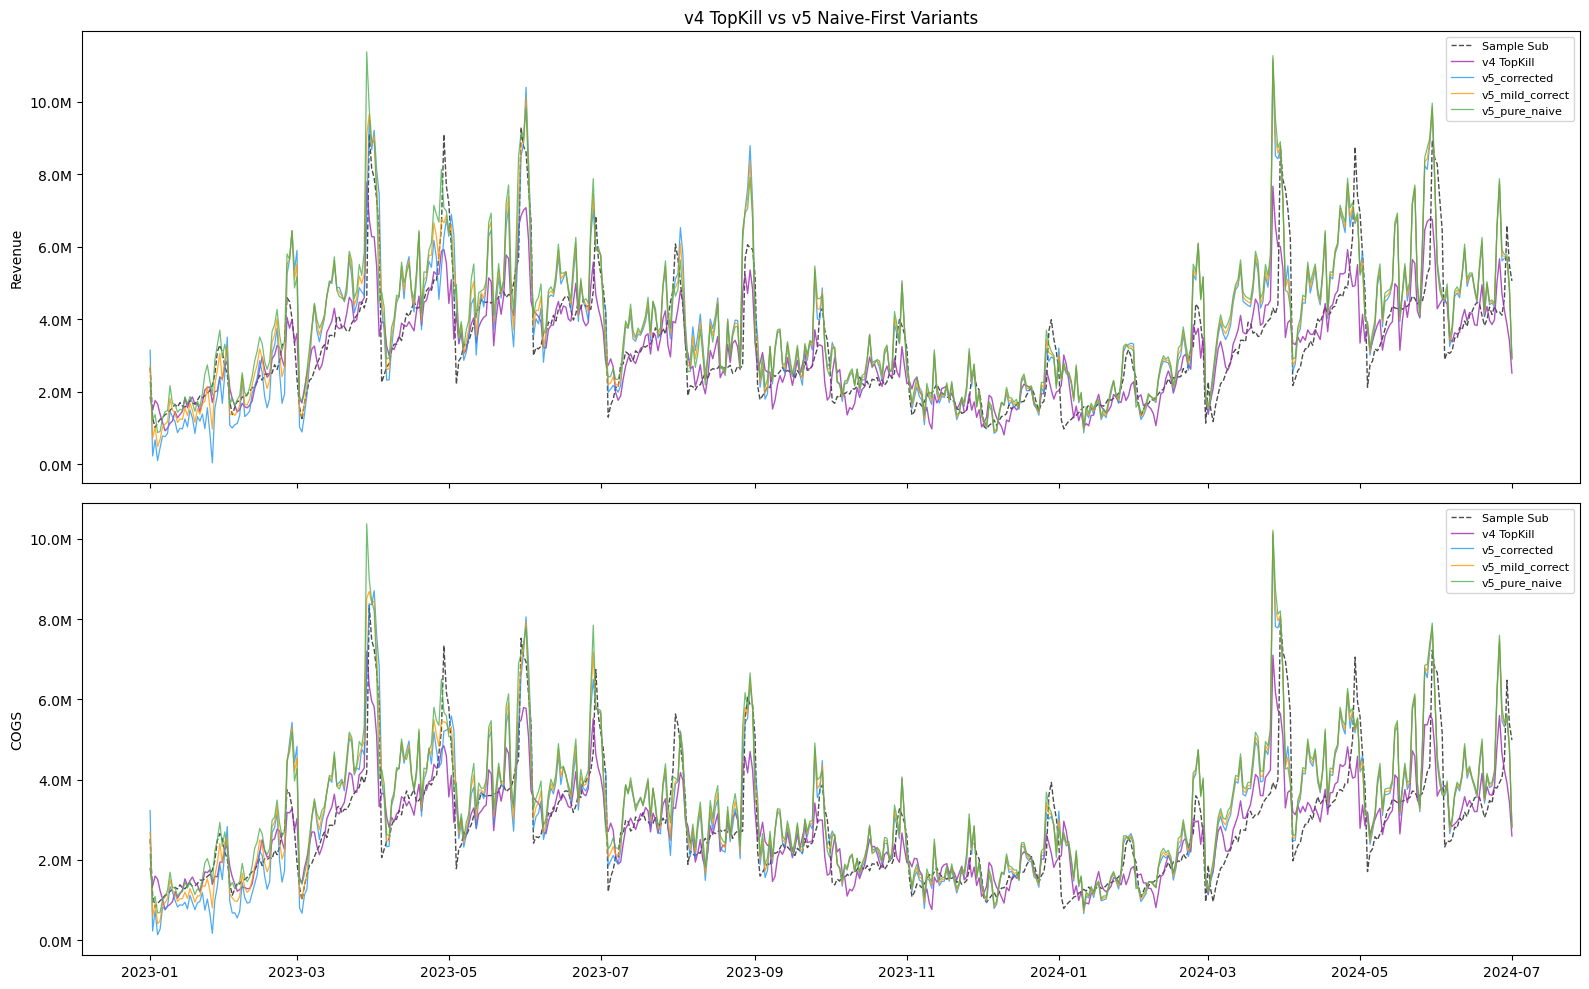


=== Forecast Mean Summary ===
Submission                   Revenue Mean       COGS Mean
-------------------------------------------------------
Sample Sub                      3,249,795       2,783,810
v4 TopKill                      3,154,655       2,762,379
v5_corrected                    3,715,869       3,127,760
v5_mild_correct                 3,821,413       3,220,733
v5_pure_naive                   3,926,956       3,313,707

→ Next: Run 04_breakthrough.ipynb


In [26]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
colors = {'v4': '#9C27B0', 'v5_pure_naive': '#4CAF50',
          'v5_mild_correct': '#FF9800', 'v5_corrected': '#2196F3',
          'sample_sub': 'black'}

for ax_idx, col in enumerate(['Revenue', 'COGS']):
    ax = axes[ax_idx]

    # Sample submission as reference
    ax.plot(df_sample.Date, df_sample[col], color=colors['sample_sub'],
            lw=1, ls='--', alpha=0.7, label='Sample Sub')

    # v4
    ax.plot(forecast_dates, v4_results[col], color=colors['v4'],
            lw=1, label='v4 TopKill', alpha=0.8)

    # v5 variants
    for variant, strength in VARIANTS.items():
        pred = v5_backbones[col] + strength * v5_corrections[col]
        pred = np.maximum(pred, 0)
        ax.plot(forecast_dates, pred, color=colors.get(f'v5_{variant}', 'grey'),
                lw=0.9, label=f'v5_{variant}', alpha=0.8)

    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.set_ylabel(col)
    ax.legend(loc='upper right', fontsize=8)

axes[0].set_title('v4 TopKill vs v5 Naive-First Variants')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.show()

# Summary table
print('\n=== Forecast Mean Summary ===')
print(f'{"Submission":<25} {"Revenue Mean":>15} {"COGS Mean":>15}')
print('-' * 55)
print(f'{"Sample Sub":<25} {df_sample.Revenue.mean():>15,.0f} {df_sample.COGS.mean():>15,.0f}')
print(f'{"v4 TopKill":<25} {v4_results["Revenue"].mean():>15,.0f} {v4_results["COGS"].mean():>15,.0f}')
for variant, strength in VARIANTS.items():
    rv = np.maximum(v5_backbones["Revenue"] + strength*v5_corrections["Revenue"], 0).mean()
    cg = np.maximum(v5_backbones["COGS"] + strength*v5_corrections["COGS"], 0).mean()
    print(f'{f"v5_{variant}":<25} {rv:>15,.0f} {cg:>15,.0f}')

print('\n→ Next: Run 04_breakthrough.ipynb')